# Spaceship Titanic: Tree-Based Classification (Kaggle Home Task)

**Competition:** [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic) (Kaggle, prediction competition)
**Problem type:** binary classification (`Transported` = True / False)
**Models used:** Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM (+ Logistic Regression baseline)

## 1. Why this competition
- It is a clean **supervised tabular classification** problem, so every model in the manual (tree, forest, boosting, XGBoost, LightGBM) applies directly.
- It is richer than the classic Titanic task: **every column has missing values**, and two columns carry hidden structure (`PassengerId` = group + number, `Cabin` = deck / number / side). That rewards real data cleaning and feature engineering instead of copy-paste.
- Passengers travel in **groups**, so the validation strategy matters (a naive split leaks information between related passengers). This lets me discuss validation properly.
- The dataset is small (8,693 training rows), so all five models and a tuning search run in minutes.

## 2. Objective and evaluation metric
- **Objective:** predict whether a passenger was transported to another dimension during the spacetime anomaly, using the passenger's records (home planet, cryosleep status, cabin, destination, age, VIP status, spending on ship amenities, name).
- **Metric:** **classification accuracy**, the share of test passengers whose `Transported` value is predicted correctly.
- **Submission format:** a CSV with two columns, `PassengerId` and `Transported` (True / False), one row per test passenger.
- **Files:** `train.csv` (8,693 rows, with target), `test.csv` (4,277 rows, no target), `sample_submission.csv`.

## 3. Load and inspect the data

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')
rs = 42

data_dir = Path('/kaggle/input/spaceship-titanic')
if not data_dir.exists():
    data_dir = Path('.')
out_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')

train = pd.read_csv(data_dir / 'train.csv')
test = pd.read_csv(data_dir / 'test.csv')
sample_sub = pd.read_csv(data_dir / 'sample_submission.csv')

print('train:', train.shape, '| test:', test.shape, '| sample submission:', sample_sub.shape)
train.head()

train: (8693, 14) | test: (4277, 13) | sample submission: (4277, 2)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [3]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


## 4. Data cleaning and EDA

### 4.1 Data quality checks

In [4]:
miss = pd.DataFrame({
    'train_missing': train.isnull().sum(),
    'train_pct': (train.isnull().mean() * 100).round(2),
    'test_missing': test.isnull().sum().reindex(train.columns),
}).drop(index='Transported')
print(miss)

print('\nduplicate rows in train:', train.duplicated().sum())
print('PassengerId unique:', train['PassengerId'].is_unique)

train_groups = set(train['PassengerId'].str[:4])
test_groups = set(test['PassengerId'].str[:4])
print('groups in train:', len(train_groups), '| groups shared between train and test:', len(train_groups & test_groups))

              train_missing  train_pct  test_missing
PassengerId               0       0.00           0.0
HomePlanet              201       2.31          87.0
CryoSleep               217       2.50          93.0
Cabin                   199       2.29         100.0
Destination             182       2.09          92.0
Age                     179       2.06          91.0
VIP                     203       2.34          93.0
RoomService             181       2.08          82.0
FoodCourt               183       2.11         106.0
ShoppingMall            208       2.39          98.0
Spa                     183       2.11         101.0
VRDeck                  188       2.16          80.0
Name                    200       2.30          94.0

duplicate rows in train: 0
PassengerId unique: True
groups in train: 6217 | groups shared between train and test: 0


**What this tells us**
- Every feature column has about 2% missing values, in both train and test, so no column should be dropped, but every column needs an imputation plan.
- There are no duplicate rows and `PassengerId` is unique.
- **No group appears in both train and test.** The test set was split by group, so my validation must also keep each group inside a single fold (otherwise CV scores are optimistic because relatives look alike). I use `StratifiedGroupKFold` for this.

### 4.2 Logical consistency checks (cryosleep and spending)

In [5]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
total = train[spend_cols].sum(axis=1)

print('spending when in cryosleep (should be 0):', (total[train['CryoSleep'] == True] > 0).sum(), 'rows')
print('mean total spend, cryosleep=True :', total[train['CryoSleep'] == True].mean())
print('mean total spend, cryosleep=False:', total[train['CryoSleep'] == False].mean())
print('spend > 0 but CryoSleep missing  :', ((total > 0) & train['CryoSleep'].isnull()).sum(), 'rows')

spending when in cryosleep (should be 0): 0 rows
mean total spend, cryosleep=True : 0.0
mean total spend, cryosleep=False: 2248.2996874425444
spend > 0 but CryoSleep missing  : 119 rows


Passengers in cryosleep are confined to their cabins, and the data confirms it: they spend nothing. This gives two **cleaning rules** that are better than a blind median or mode fill:
1. If `CryoSleep` is True, any missing amenity spend is **0**.
2. If spending is above 0, a missing `CryoSleep` must be **False**.

### 4.3 Target and univariate EDA

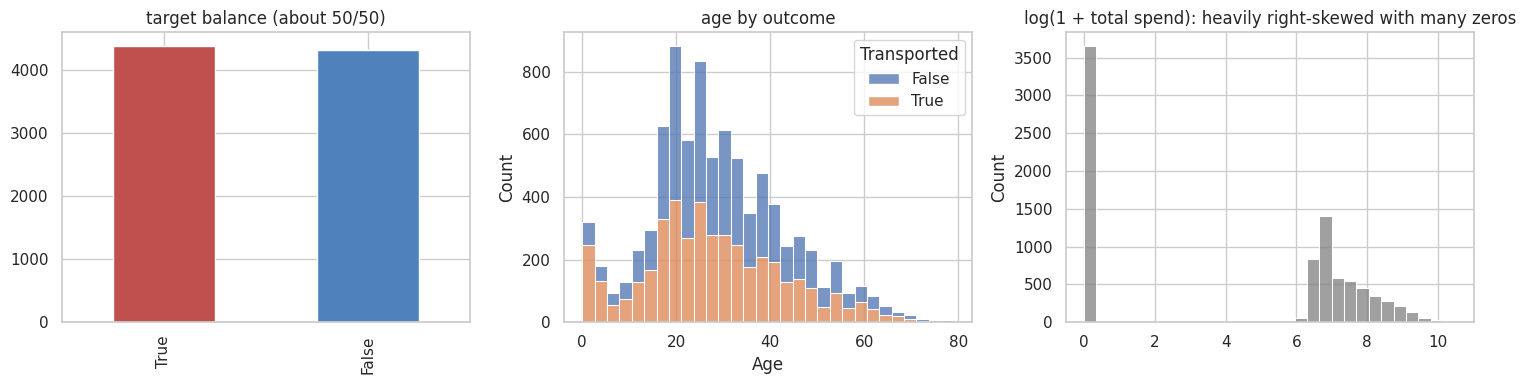

Transported
True     0.504
False    0.496
Name: proportion, dtype: float64
share of passengers with zero total spend: 0.42


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

train['Transported'].value_counts().plot(kind='bar', ax=ax[0], color=['#c0504d', '#4f81bd'])
ax[0].set_title('target balance (about 50/50)')
ax[0].set_xlabel('')

sns.histplot(data=train, x='Age', hue='Transported', bins=30, multiple='stack', ax=ax[1])
ax[1].set_title('age by outcome')

sns.histplot(np.log1p(total), bins=30, ax=ax[2], color='gray')
ax[2].set_title('log(1 + total spend): heavily right-skewed with many zeros')

plt.tight_layout()
plt.show()

print(train['Transported'].value_counts(normalize=True).round(3))
print('share of passengers with zero total spend:', round((total == 0).mean(), 3))

### 4.4 Relationship with the target

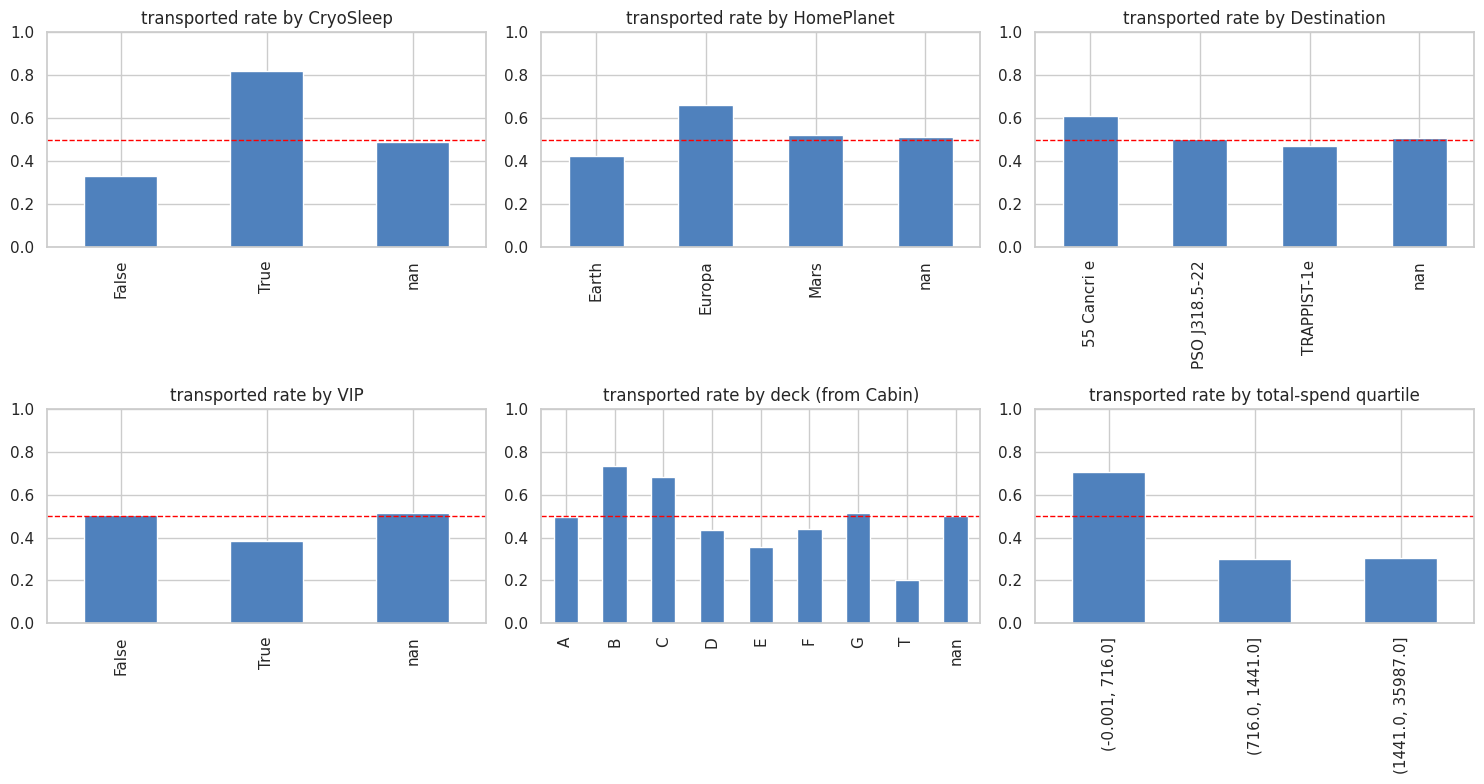

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, c in zip(ax.ravel(), ['CryoSleep', 'HomePlanet', 'Destination', 'VIP']):
    train.groupby(c, dropna=False)['Transported'].mean().plot(kind='bar', ax=a, color='#4f81bd')
    a.set_title('transported rate by ' + c)
    a.set_ylim(0, 1)
    a.axhline(0.5, color='red', linestyle='--', linewidth=1)
    a.set_xlabel('')

deck = train['Cabin'].str.split('/').str[0]
train.groupby(deck, dropna=False)['Transported'].mean().plot(kind='bar', ax=ax[1, 1], color='#4f81bd')
ax[1, 1].set_title('transported rate by deck (from Cabin)')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].axhline(0.5, color='red', linestyle='--', linewidth=1)
ax[1, 1].set_xlabel('')

train.groupby(pd.qcut(total, 4, duplicates='drop'))['Transported'].mean().plot(kind='bar', ax=ax[1, 2], color='#4f81bd')
ax[1, 2].set_title('transported rate by total-spend quartile')
ax[1, 2].set_ylim(0, 1)
ax[1, 2].axhline(0.5, color='red', linestyle='--', linewidth=1)
ax[1, 2].set_xlabel('')

plt.tight_layout()
plt.show()

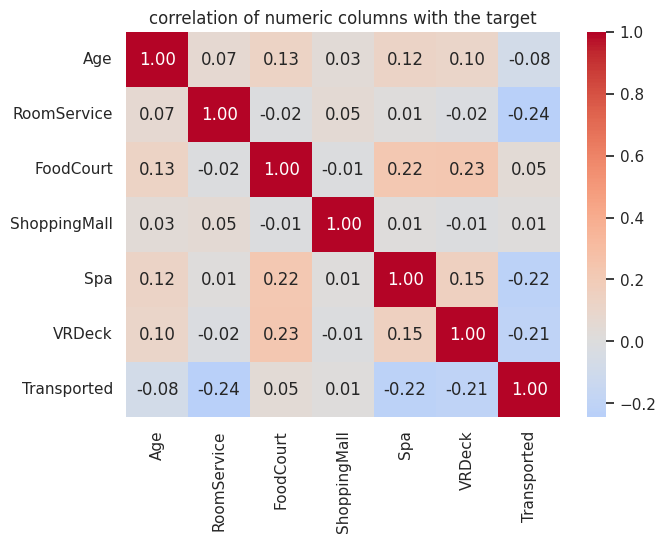

In [8]:
num_view = train[['Age'] + spend_cols].copy()
num_view['Transported'] = train['Transported'].astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(num_view.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('correlation of numeric columns with the target')
plt.show()

**EDA findings**
- The target is balanced (50.4% / 49.6%), so accuracy is a fair metric and no resampling is needed.
- **`CryoSleep` is the strongest single signal:** 81.8% of cryosleep passengers were transported versus 32.9% of the others.
- `HomePlanet`, `Destination` and `deck` all shift the rate: Europa (65.9%) and decks B (73.4%) and C (68.0%) are above the 50% line, while Earth (42.4%) and decks D, E and F (36% to 44%) are below it.
- Spending is zero-inflated (42% of passengers spent nothing) and heavily skewed. Passengers in the lowest spend quartile (including all cryosleepers) are transported 70.5% of the time versus about 30% in the upper two quartiles. Trees handle the skew without a transform, but a `total_spend` feature and a zero-spend flag still help.
- Children aged 12 or under are transported 70.0% of the time, versus about 46% to 50% for adults.
- Linear correlations of single numeric columns with the target are modest (the largest is about -0.25 for `RoomService`), which suggests interaction effects that tree models can pick up.

## 5. Feature engineering

All new features are built by one function, applied to train and test together so the encodings are identical. Only **features** (never the target) are used for the group and family counts, so there is no target leakage.

| new feature | how it is built | why |
|---|---|---|
| `group`, `group_size`, `solo` | first 4 characters of `PassengerId`, then counts | relatives travel together and tend to share an outcome |
| `deck`, `cabin_num`, `side` | split `Cabin` as deck / number / side | deck and side carry location in the ship |
| `total_spend`, `n_services`, `no_spend` | sum of the 5 amenities, number used, zero flag | compresses the skewed spend columns |
| `family_size` | count of passengers with the same surname | family units behave together |
| `is_child`, `age_group` | bins of `Age` | non-linear age effect |
| group-based fill | `HomePlanet`, `deck`, `side` filled from other members of the same group | passengers in a group share a home planet |
| cryosleep rules | cryosleep = spend 0, and spend above 0 = not cryosleep | follows the logical checks in 4.2 |

In [9]:
def make_features(df):
    d = df.copy()

    d['group'] = d['PassengerId'].str[:4]
    d['group_size'] = d.groupby('group')['PassengerId'].transform('count')
    d['solo'] = (d['group_size'] == 1).astype(int)

    cab = d['Cabin'].str.split('/', expand=True)
    d['deck'] = cab[0]
    d['cabin_num'] = pd.to_numeric(cab[1])
    d['side'] = cab[2]

    d.loc[d['CryoSleep'] == True, spend_cols] = d.loc[d['CryoSleep'] == True, spend_cols].fillna(0)
    d['total_spend'] = d[spend_cols].sum(axis=1)
    d.loc[d['CryoSleep'].isnull() & (d['total_spend'] > 0), 'CryoSleep'] = False

    d['n_services'] = (d[spend_cols].fillna(0) > 0).sum(axis=1)
    d['no_spend'] = (d['total_spend'] == 0).astype(int)

    d['surname'] = d['Name'].str.split().str[-1]
    d['family_size'] = d.groupby('surname')['PassengerId'].transform('count')
    d['family_size'] = d['family_size'].fillna(1)

    d['is_child'] = (d['Age'] < 13).astype(int)
    d['age_group'] = pd.cut(d['Age'], [-1, 12, 17, 25, 40, 60, 120],
                            labels=['child', 'teen', 'young', 'adult', 'middle', 'senior']).astype(object)

    for c in ['HomePlanet', 'deck', 'side']:
        first_known = d.groupby('group')[c].transform(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
        d[c] = d[c].fillna(first_known)

    for c in ['CryoSleep', 'VIP']:
        d[c] = d[c].map({True: 'yes', False: 'no'})

    return d

full = pd.concat([train.drop(columns='Transported'), test], keys=['train', 'test'])
full_fe = make_features(full)

train_fe = full_fe.loc['train'].copy()
test_fe = full_fe.loc['test'].copy()

y = train['Transported'].astype(int).values
groups = train_fe['group'].values

new_cols = ['group_size', 'solo', 'deck', 'cabin_num', 'side', 'total_spend', 'n_services', 'no_spend', 'family_size', 'is_child', 'age_group']
train_fe[new_cols].head()

,group_size,solo,deck,cabin_num,side,total_spend,n_services,no_spend,family_size,is_child,age_group
0,1,1,B,0.0,P,0.0,0,1,3.0,0,adult
1,1,1,F,0.0,S,736.0,5,0,4.0,0,young
2,2,0,A,0.0,S,10383.0,4,0,7.0,0,middle
3,2,0,A,0.0,S,5176.0,4,0,7.0,0,adult
4,1,1,F,1.0,S,1091.0,5,0,9.0,0,teen


In [10]:
print('missing values left in train after rule-based cleaning:')
print(train_fe.drop(columns=['Name', 'Cabin']).isnull().sum()[lambda s: s > 0])

missing values left in train after rule-based cleaning:
HomePlanet      111
CryoSleep        98
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
deck             99
cabin_num       199
side             99
surname         200
age_group       179
dtype: int64


The few remaining gaps are filled **inside the model pipeline** (median for numbers, most frequent for categories). Fitting the imputer inside each cross-validation fold means the validation rows never influence the fill values, which avoids leakage.

## 6. Preprocessing pipelines and validation strategy

- **Trees / boosting:** impute, then `OrdinalEncoder` for categories. No scaling is needed because trees split on thresholds.
- **Logistic regression (baseline):** impute, scale numbers, one-hot encode categories.
- **Validation:** `StratifiedGroupKFold` with 5 folds. It keeps the class ratio in every fold **and** keeps each travel group inside a single fold, mirroring how the Kaggle test set was built.

In [11]:
raw_num = ['Age'] + spend_cols
raw_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

num_feats = raw_num + ['total_spend', 'n_services', 'no_spend', 'group_size', 'solo', 'cabin_num', 'family_size', 'is_child']
cat_feats = raw_cat + ['deck', 'side', 'age_group']

def tree_prep(num, cat):
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat)
    ], verbose_feature_names_out=False)

def linear_prep(num, cat):
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat)
    ])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=rs)

x_raw = train_fe[raw_num + raw_cat]
x_fe = train_fe[num_feats + cat_feats]
x_test_fe = test_fe[num_feats + cat_feats]

def cv_score(model, x):
    s = cross_val_score(model, x, y, cv=cv, groups=groups, scoring='accuracy', n_jobs=-1)
    return s.mean(), s.std(), s

print('features used:', x_fe.shape[1], '| rows:', x_fe.shape[0])

features used: 21 | rows: 8693


## 7. Baseline models

In [12]:
baseline_rows = []

m, s, _ = cv_score(DummyClassifier(strategy='most_frequent'), x_raw)
baseline_rows.append(('majority class', 'raw', m, s))

lr_raw = Pipeline([('prep', linear_prep(raw_num, raw_cat)), ('m', LogisticRegression(max_iter=2000))])
m, s, _ = cv_score(lr_raw, x_raw)
baseline_rows.append(('logistic regression', 'raw', m, s))

baseline = pd.DataFrame(baseline_rows, columns=['model', 'features', 'cv_accuracy', 'cv_std'])
baseline.round(4)

,model,features,cv_accuracy,cv_std
0,majority class,raw,0.5036,0.0001
1,logistic regression,raw,0.7866,0.0053


The majority-class dummy shows the floor (about 50%, because the target is balanced). **Logistic regression on the raw columns is my baseline**: every tree model below must beat it to justify its extra complexity.

## 8. Train five tree-based models and compare with cross-validation

All five models use the engineered features and the same group-aware folds, so the comparison is fair. I also run Random Forest on the **raw** features to measure how much feature engineering helped.

In [13]:
models = {
    'decision tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=rs),
    'random forest': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=10, max_features='sqrt', n_jobs=-1, random_state=rs),
    'gradient boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=rs),
    'xgboost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=rs, n_jobs=1),
    'lightgbm': LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=rs, verbosity=-1, n_jobs=1),
}

rows = []
fold_scores = {}
for name, mdl in models.items():
    pipe = Pipeline([('prep', tree_prep(num_feats, cat_feats)), ('m', mdl)])
    mean, std, s = cv_score(pipe, x_fe)
    fold_scores[name] = s
    rows.append((name, 'engineered', mean, std))

rf_raw = Pipeline([('prep', tree_prep(raw_num, raw_cat)), ('m', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=10, max_features='sqrt', n_jobs=-1, random_state=rs))])
mean, std, _ = cv_score(rf_raw, x_raw)
rows.append(('random forest', 'raw (ablation)', mean, std))

results = pd.DataFrame(rows, columns=['model', 'features', 'cv_accuracy', 'cv_std'])
results = pd.concat([baseline, results], ignore_index=True).sort_values('cv_accuracy', ascending=False).reset_index(drop=True)
results.round(4)

,model,features,cv_accuracy,cv_std
0,xgboost,engineered,0.8112,0.0079
1,lightgbm,engineered,0.8100,0.0039
2,gradient boosting,engineered,0.8046,0.0056
3,random forest,engineered,0.8005,0.0060
4,random forest,raw (ablation),0.7978,0.0042
5,logistic regression,raw,0.7866,0.0053
6,decision tree,engineered,0.7826,0.0062
7,majority class,raw,0.5036,0.0001


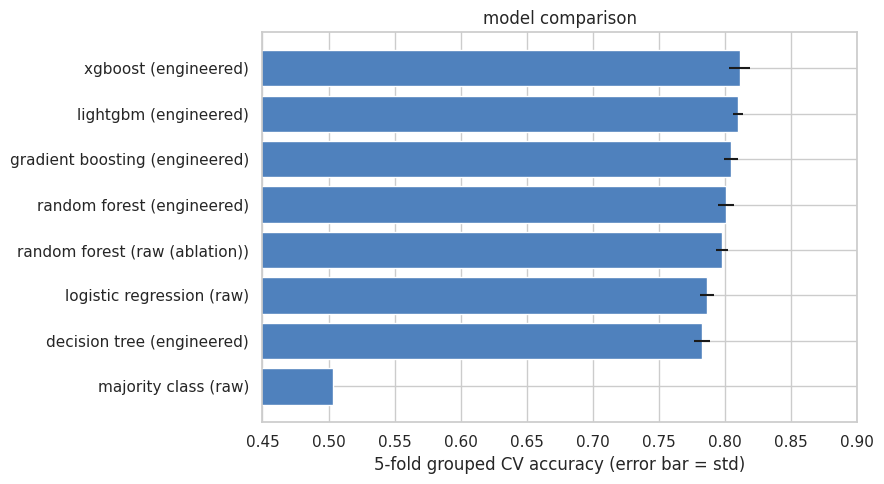

In [14]:
plot_df = results.copy()
plot_df['label'] = plot_df['model'] + ' (' + plot_df['features'] + ')'
plot_df = plot_df.sort_values('cv_accuracy')

plt.figure(figsize=(9, 5))
plt.barh(plot_df['label'], plot_df['cv_accuracy'], xerr=plot_df['cv_std'], color='#4f81bd')
plt.xlim(0.45, 0.9)
plt.xlabel('5-fold grouped CV accuracy (error bar = std)')
plt.title('model comparison')
plt.tight_layout()
plt.show()

In [15]:
best_default = results[(results['features'] == 'engineered')].iloc[0]
print('best default model:', best_default['model'], '| cv accuracy:', round(best_default['cv_accuracy'], 4))

lr_cv = results[results['model'] == 'logistic regression']['cv_accuracy'].iloc[0]
rf_eng = results[(results['model'] == 'random forest') & (results['features'] == 'engineered')]['cv_accuracy'].iloc[0]
rf_rw = results[(results['model'] == 'random forest') & (results['features'] == 'raw (ablation)')]['cv_accuracy'].iloc[0]
print('gain of best tree model over the logistic baseline:', round(best_default['cv_accuracy'] - lr_cv, 4))
print('gain from feature engineering (random forest, engineered minus raw):', round(rf_eng - rf_rw, 4))

best default model: xgboost | cv accuracy: 0.8112
gain of best tree model over the logistic baseline: 0.0246
gain from feature engineering (random forest, engineered minus raw): 0.0028


### Reading the comparison
- **Boosting wins:** XGBoost (0.811) and LightGBM (0.810) are statistically indistinguishable, gradient boosting (0.805) is close behind, and the random forest (0.801) is about one point lower. Fold standard deviations are 0.004 to 0.008, so only differences larger than roughly one point carry real evidence.
- **The best tree model beats the logistic baseline (0.787) by about 2.5 points.** Not every tree beats it: the single decision tree (0.783) is slightly *below* the baseline, because one tree has high variance and only one view of the data. Ensembling is what makes trees pay off here.
- **Feature engineering helped only a little:** the random forest scores 0.8005 on engineered features versus 0.7978 on raw ones, a gain of about 0.3 points, which is within noise. Most of the signal was already in the raw columns (cryosleep, spending, home planet); the larger gain over the baseline comes from using non-linear models.
- I choose LightGBM for tuning because it ties for the best score, trains fastest, and has many useful parameters.

## 9. Hyperparameter tuning (LightGBM)

I tune LightGBM with `RandomizedSearchCV` (40 random configurations) using the **same grouped folds**. Parameters searched: number of trees, learning rate, tree complexity (`num_leaves`, `max_depth`, `min_child_samples`), row and column sampling, and L2 regularisation.

In [16]:
from scipy.stats import randint, uniform, loguniform

lgbm_pipe = Pipeline([
    ('prep', tree_prep(num_feats, cat_feats)),
    ('m', LGBMClassifier(subsample_freq=1, random_state=rs, verbosity=-1, n_jobs=1))
])

param_dist = {
    'm__n_estimators': randint(100, 700),
    'm__learning_rate': loguniform(0.01, 0.2),
    'm__num_leaves': randint(8, 64),
    'm__max_depth': [-1, 3, 4, 5, 6, 8],
    'm__min_child_samples': randint(10, 80),
    'm__subsample': uniform(0.6, 0.4),
    'm__colsample_bytree': uniform(0.5, 0.5),
    'm__reg_lambda': uniform(0, 5),
}

search = RandomizedSearchCV(lgbm_pipe, param_dist, n_iter=40, cv=cv, scoring='accuracy',
                            random_state=rs, n_jobs=-1, refit=True)
search.fit(x_fe, y, groups=groups)

print('best cv accuracy:', round(search.best_score_, 4))
for k, v in search.best_params_.items():
    print(' ', k.replace('m__', ''), '=', round(v, 4) if isinstance(v, float) else v)

best cv accuracy: 0.8144
  colsample_bytree = 0.9144
  learning_rate = 0.0291
  max_depth = 5
  min_child_samples = 69
  n_estimators = 479
  num_leaves = 52
  reg_lambda = 0.7046
  subsample = 0.9209


In [17]:
default_lgbm = results[(results['model'] == 'lightgbm')]['cv_accuracy'].iloc[0]
print('lightgbm default :', round(default_lgbm, 4))
print('lightgbm tuned   :', round(search.best_score_, 4))
print('improvement      :', round(search.best_score_ - default_lgbm, 4))

cvres = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
cvres[['rank_test_score', 'mean_test_score', 'std_test_score']].head(5).round(4)

lightgbm default : 0.81
lightgbm tuned   : 0.8144
improvement      : 0.0045


,rank_test_score,mean_test_score,std_test_score
9,1,0.8144,0.0063
25,2,0.8142,0.0075
28,3,0.8131,0.0077
21,4,0.8126,0.0068
26,5,0.8124,0.0095


Tuning raised LightGBM from 0.8100 to 0.8144 (+0.45 points), while the fold standard deviation is about 0.006, so I treat the gain as modest rather than decisive. The top five configurations all score between 0.812 and 0.814, which shows the score surface is flat around the optimum.

One caveat: 0.8144 is the best of 40 trials selected on the same folds it is reported on, so it is slightly optimistic. The leaderboard score is the honest test.

## 10. Final model diagnostics

                 precision    recall  f1-score   support

not transported       0.82      0.81      0.81      4315
    transported       0.81      0.82      0.82      4378

       accuracy                           0.81      8693
      macro avg       0.81      0.81      0.81      8693
   weighted avg       0.81      0.81      0.81      8693



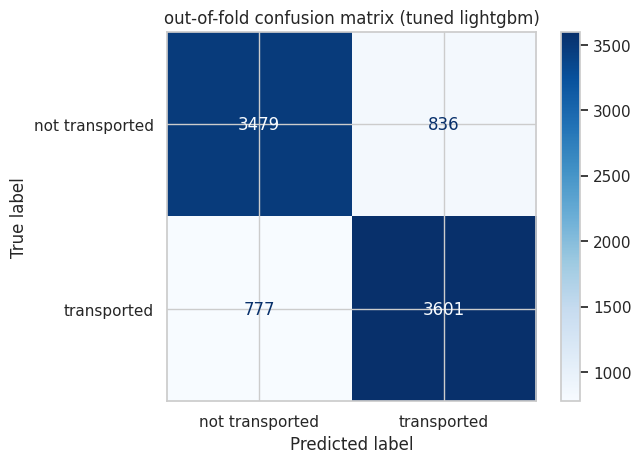

In [18]:
oof = cross_val_predict(search.best_estimator_, x_fe, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, oof, target_names=['not transported', 'transported']))
ConfusionMatrixDisplay(confusion_matrix(y, oof), display_labels=['not transported', 'transported']).plot(cmap='Blues')
plt.title('out-of-fold confusion matrix (tuned lightgbm)')
plt.show()

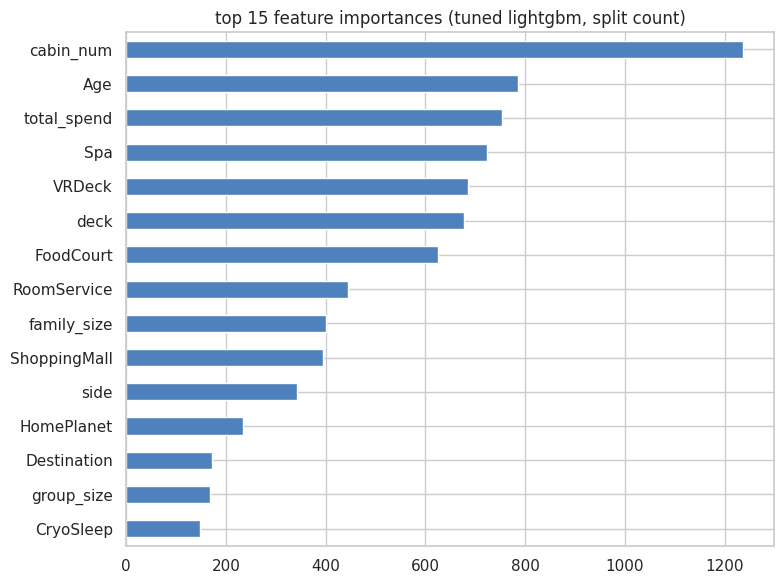

In [19]:
best_pipe = search.best_estimator_
names = best_pipe.named_steps['prep'].get_feature_names_out()
imp = pd.Series(best_pipe.named_steps['m'].feature_importances_, index=names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
imp.tail(15).plot(kind='barh', color='#4f81bd')
plt.title('top 15 feature importances (tuned lightgbm, split count)')
plt.tight_layout()
plt.show()

By split count, the most used features are `cabin_num`, `Age`, `total_spend`, `Spa`, `deck`, `VRDeck`, `FoodCourt` and `RoomService`, with the engineered `total_spend`, `cabin_num`, `deck` and `family_size` among the top ten. Two cautions when reading this:
- `CryoSleep` does not appear near the top even though it was the strongest signal in the EDA, because zero spending (`total_spend`, `Spa`, `VRDeck`...) already encodes it, so the model splits on those columns instead.
- Split-count importance favours continuous columns with many possible split points (`cabin_num`, `Age`), so it overstates them relative to binary columns. Permutation importance would be a fairer check.

## 11. Generate the Kaggle submission file

The tuned pipeline was refit on **all** training rows by `RandomizedSearchCV(refit=True)`, so it can predict the test set directly. The submission has the required two columns, with `Transported` as True / False.

In [20]:
test_pred = search.best_estimator_.predict(x_test_fe)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred.astype(bool)
})
submission.to_csv(out_dir / 'submission.csv', index=False)

assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert (submission['PassengerId'] == sample_sub['PassengerId']).all()
assert submission['Transported'].isnull().sum() == 0

print('saved:', out_dir / 'submission.csv')
print(submission.shape)
print(submission['Transported'].value_counts(normalize=True).round(3))
submission.head()

saved: submission.csv
(4277, 2)
Transported
True     0.515
False    0.485
Name: proportion, dtype: float64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 12. Submit to Kaggle and record the leaderboard score

1. Go to the competition page, then **Submit Predictions**.
2. Upload `submission.csv`, add a short description (for example "tuned LightGBM, grouped CV"), and submit.
3. Type the **public score** shown by Kaggle into the cell below and re-run it. The cell prints the comparison with my cross-validation estimate and a short interpretation.

In [21]:
lb_score = None

cv_est = search.best_score_
cv_std = cvres.iloc[0]['std_test_score']
print('cross-validation estimate :', round(cv_est, 4), '+/-', round(cv_std, 4))

if lb_score is None:
    print('leaderboard score         : not recorded yet, set lb_score to your Kaggle public score')
else:
    gap = lb_score - cv_est
    print('leaderboard score         :', lb_score)
    print('difference (lb - cv)      :', round(gap, 4))
    if abs(gap) <= 2 * cv_std:
        print('interpretation: the public score is within about two fold-standard-deviations of the CV estimate, so the grouped validation was a reliable guide and there are no signs of leakage or overfitting to the validation folds.')
    elif gap < 0:
        print('interpretation: the public score is clearly below the CV estimate, which suggests optimistic validation (a leak, or tuning that overfit the folds) or a shift between train and test.')
    else:
        print('interpretation: the public score is clearly above the CV estimate; the public test set may simply be an easier sample, so I would not read it as a better model.')

cross-validation estimate : 0.8144 +/- 0.0063
leaderboard score         : not recorded yet, set lb_score to your Kaggle public score


### Explaining the result
*(Complete this paragraph after you see your score; the points below show what to address.)*

- Compare the public score with the cross-validation estimate printed above. A small gap means the grouped CV was a trustworthy guide; a large negative gap would signal leakage or overfitting.
- The public leaderboard uses only part of the test set and accuracy on 4,277 rows has a sampling error of roughly one percentage point, so tiny score differences between models are not meaningful.
- Say where the score sits relative to the baseline (logistic regression) and the majority-class floor, and which features and decisions (cryosleep rules, spend features, group-aware validation, tuning) you think contributed most.

## 13. Limitations and possible improvements

### Limitations
1. **Accuracy is the only metric and the validation noise is large relative to the differences.** With about 8.7k training rows, the fold standard deviation is 0.004 to 0.008, so XGBoost vs LightGBM, and tuned vs untuned LightGBM (+0.45 points), cannot be separated with confidence. The 0.8144 tuning score is also the best of 40 trials, so it is mildly optimistic.
2. **Simple imputation and rule-based cleaning.** Remaining missing values use the median or most frequent value, and the group-based fill assumes that people in one group share a home planet, deck and side. These are plausible rules but not guaranteed, and imputation uncertainty is ignored by the model.
3. **Weak and partly noisy engineered signals.** Surname-based `family_size` depends on the `Name` column (which is itself missing for about 2% of passengers), and surnames can be shared by unrelated people, so the feature is noisy.
4. **Limited tuning budget.** Only one model was tuned, with 40 random trials, so a better configuration (or a better model family) may have been missed.

### Possible improvements
1. **Ensembling or stacking.** Average the predicted probabilities of LightGBM, XGBoost and Random Forest (or stack them with a logistic regression meta-model). Models with different biases usually add about half a point to a point of accuracy.
2. **Richer features and imputation.** Add group-level aggregates (group total spend, share of the group in cryosleep, neighbouring cabin information) and use model-based imputation (iterative or KNN imputer) instead of median and mode fills.
3. **Better tuning.** Use Bayesian optimisation (for example Optuna) with more trials and repeated grouped CV, and tune XGBoost and CatBoost too, then compare at the same budget.
4. **Check calibration and errors.** Look at which passenger types are misclassified in the out-of-fold predictions and design features for those cases.